# 07 - Composite Area Risk Score

Each LAPD area is scored on a 0–1 scale by combining four normalised components:

| Component | Definition | Weight |
|-----------|-----------|--------|
| Intensity | mean daily crimes over last 28 days | 0.35 |
| Trend     | (recent mean − long mean) / long std | 0.20 |
| Violence  | violent share over recent window | 0.20 |
| Forecast  | mean of next-7-day forecast | 0.25 |


In [1]:
# bootstrap: make src importable
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src import config, feature_engineering, risk_scoring
from src.utils import apply_plot_style
apply_plot_style()

daily = pd.read_parquet(config.DAILY_AREA_PARQUET)
daily = feature_engineering.trim_incomplete_tail(daily)
fc = pd.read_parquet(config.FEATURES_DIR / 'forecast_next7.parquet')
risk = risk_scoring.compute_area_risk(daily, fc)
risk[['area_name','risk_rank','risk_score','risk_tier','intensity','trend','violence','forecast']]

02:08:34 | INFO    | src.feature_engineering | trim_incomplete_tail: cutting at 2024-05-12 (was 2024-06-24)


,area_name,risk_rank,risk_score,risk_tier,intensity,trend,violence,forecast
0,77th Street,1,0.919752,Critical,30.107143,-0.334942,0.232914,33.806065
1,Southwest,2,0.818722,Critical,29.178571,-0.282633,0.186414,30.782517
2,N Hollywood,3,0.736590,Critical,29.678571,-0.303885,0.122878,29.004119
3,Southeast,4,0.692429,Critical,23.071429,-0.348791,0.248302,27.522729
4,Van Nuys,5,0.616544,Critical,24.500000,-0.091786,0.121537,25.091868
5,West Valley,6,0.605684,High,23.714286,-0.065291,0.130587,24.542560
6,Mission,7,0.587321,High,21.571429,-0.012009,0.174189,23.012674
7,Topanga,8,0.545814,High,23.000000,-0.168022,0.115312,23.760541
8,Devonshire,9,0.537897,High,23.178571,-0.268882,0.129883,23.608379
9,Foothill,10,0.484996,High,18.392857,0.004756,0.165056,20.652019


## Risk score visualisation

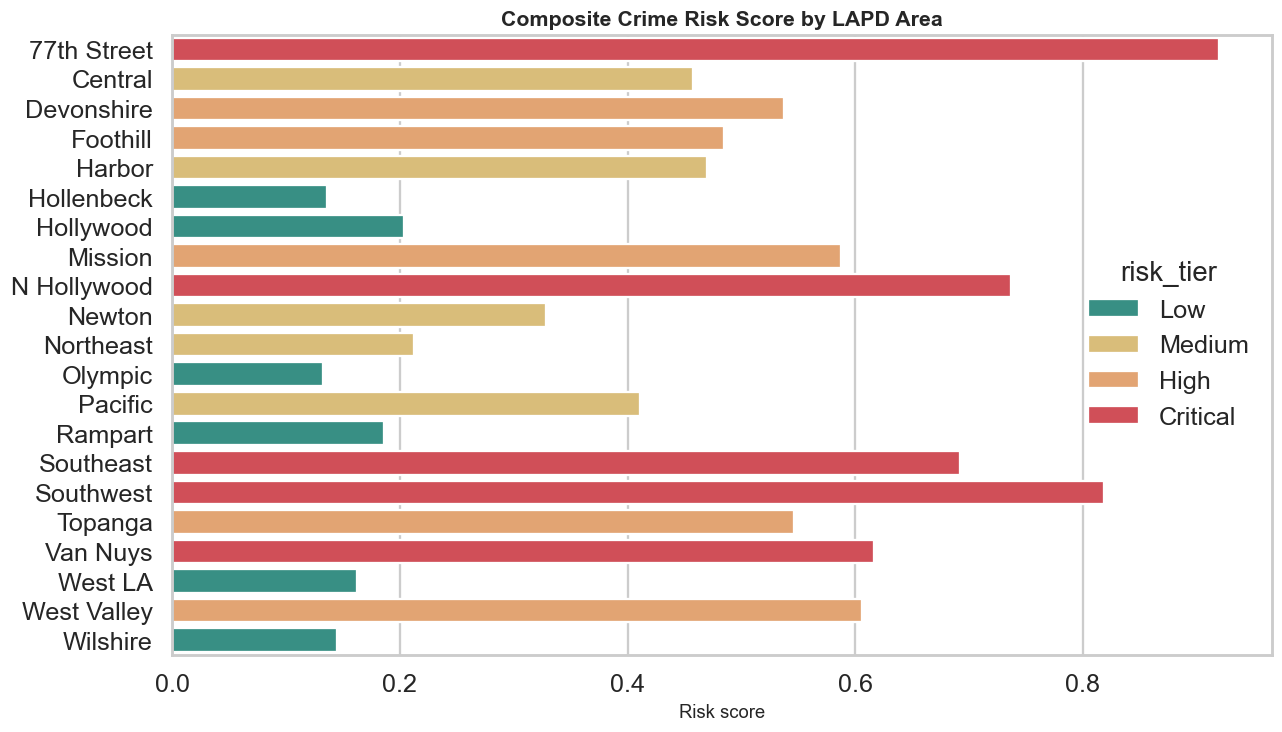

In [2]:
fig, ax = plt.subplots(figsize=(12,7))
order = risk.sort_values('risk_score')
sns.barplot(x='risk_score', y='area_name', hue='risk_tier', data=order,
            palette={'Low':'#2A9D8F','Medium':'#E9C46A','High':'#F4A261','Critical':'#E63946'}, ax=ax, dodge=False)
ax.set_title('Composite Crime Risk Score by LAPD Area'); ax.set_xlabel('Risk score'); ax.set_ylabel('');
fig.tight_layout()

## Component decomposition

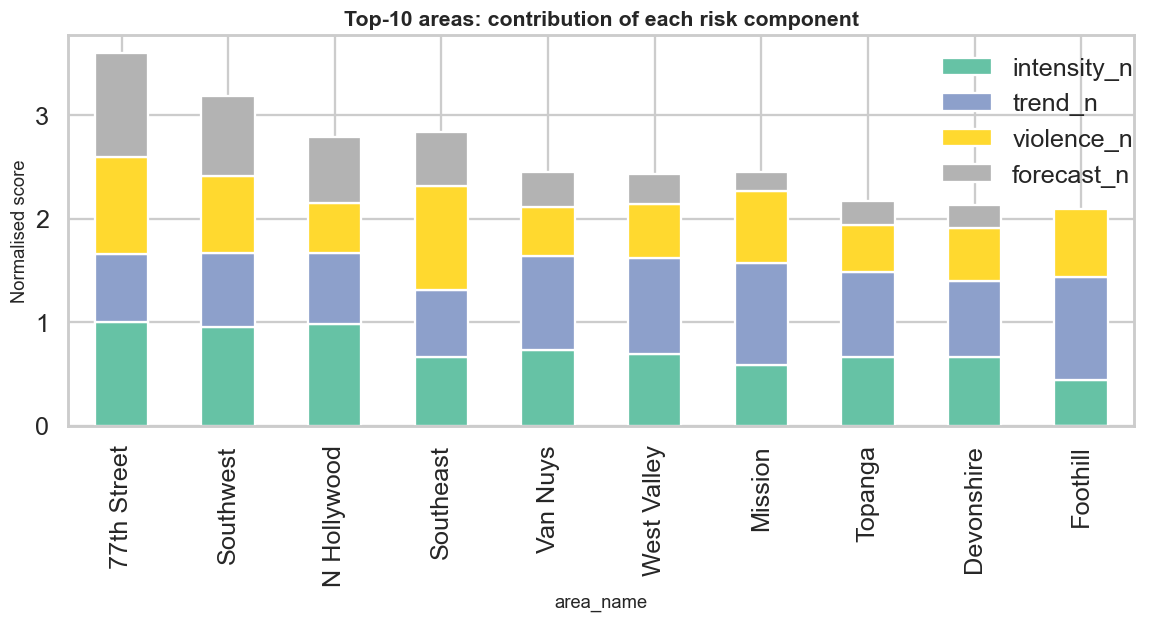

In [3]:
comp = risk.set_index('area_name')[['intensity_n','trend_n','violence_n','forecast_n']].head(10)
fig, ax = plt.subplots(figsize=(11,6))
comp.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Top-10 areas: contribution of each risk component'); ax.set_ylabel('Normalised score'); ax.legend(title='', bbox_to_anchor=(1.02,1));
fig.tight_layout()